In [15]:
import shap
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np

In [16]:
# Load the Iris dataset
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name='Species')

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42)

In [17]:
temp = X_train.copy()
temp['target'] = y_train

In [18]:
temp

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
22,4.6,3.6,1.0,0.2,0
15,5.7,4.4,1.5,0.4,0
65,6.7,3.1,4.4,1.4,1
11,4.8,3.4,1.6,0.2,0
42,4.4,3.2,1.3,0.2,0
...,...,...,...,...,...
71,6.1,2.8,4.0,1.3,1
106,4.9,2.5,4.5,1.7,2
14,5.8,4.0,1.2,0.2,0
92,5.8,2.6,4.0,1.2,1


In [19]:
# Initialize and train the Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [20]:
# Explain the model's predictions using SHAP
explainer = shap.TreeExplainer(model)

# shap_values shape: (n_samples, n_features, n_classes) for multi-class
shap_values = explainer.shap_values(X_test)
print("SHAP values shape:", shap_values.shape)
print("Expected values (base values per class):", explainer.expected_value)

SHAP values shape: (30, 4, 3)
Expected values (base values per class): [0.33733333 0.34258333 0.32008333]


In [21]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [22]:
model.classes_

array([0, 1, 2])

In [23]:
instance_index = 0  # Change this to the index of the instance you want to visualize

# Predict the class for the specified instance
predicted_class = model.predict(X_test.iloc[[instance_index]])[0]
print(f"Predicted class: {predicted_class} ({iris.target_names[predicted_class]})")

Predicted class: 1 (versicolor)


In [24]:
predicted_class

1

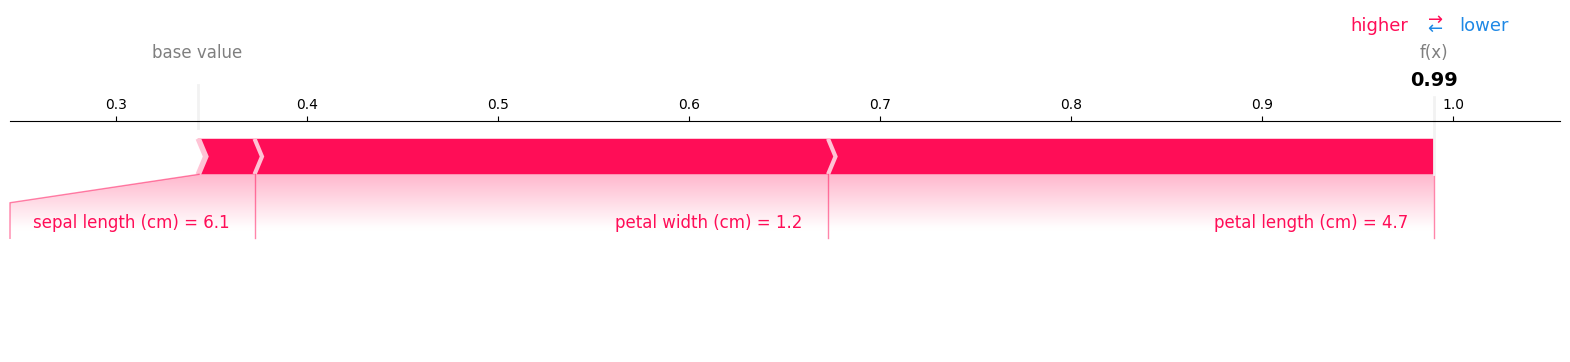

In [25]:
# Generate the SHAP force plot for the predicted class of the specified instance
# shap_values shape is (n_samples, n_features, n_classes), so we index as:
#   shap_values[instance, :, class]
shap.force_plot(explainer.expected_value[predicted_class],
                shap_values[instance_index, :, predicted_class],
                X_test.iloc[instance_index],
                feature_names=iris.feature_names,
                matplotlib=True)

## How to interpret it:

__Base Value__: This is the average model output over the dataset that was used by the SHAP explainer during initialization (or the probability of the given class in the training data, as the above example). You can think of it as the starting point before considering the effect of each individual feature in the instance being explained.

__Output Value (f(x))__: This is the actual prediction for the instance being explained by the plot. It's the final output of the model after considering the contribution of each feature.

__Feature Values__: In the plot, you can see three features with numerical values next to them indicating the actual measured value for these features in the instance being explained .

__Red and Blue Arrows (SHAP Values)__: The length of these arrows indicates the magnitude of the impact of each feature on the model's prediction.

__Blue Arrows__: They represent features that are pushing the prediction to be lower than the base value. In this case, "sepal width (cm)" with a value of21.2 is pushing the prediction lower.
__Red Arrows__: These are features that push the prediction higher. Here, "petal width (cm)" with a value of 1.5 and Petal length (cm) with a value of 4.5 are pushing the prediction higher.

__Higher ⇨ Lower__: This shows the direction of the prediction. If the features are pushing the prediction to the right (red), it means they are contributing to a higher prediction value. Conversely, if they push to the left (blue), they contribute to a lower prediction value.

__Color Intensity__: The color intensity corresponds to the feature value's impact. A deeper color means a stronger impact on the model's output.

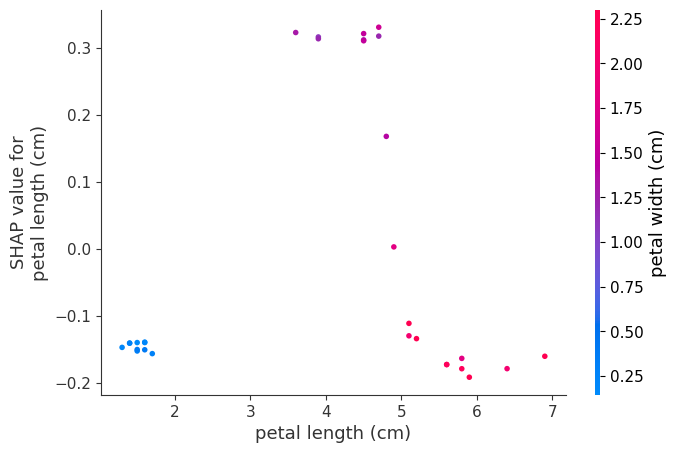

In [26]:
# Plot dependence plot for a specific feature (class 1 = versicolor)
shap.dependence_plot("petal length (cm)",
                     shap_values[:, :, 1],
                     X_test,
                     interaction_index="petal width (cm)")

## How to interpret it:

- The plot illustrates the relationship between `petal length (cm)` and its SHAP values.
- The x-axis corresponds to the actual values of `petal length (cm)` within the dataset.
- The y-axis indicates the SHAP values for the feature `petal length (cm)`, which quantify the impact of this feature on the model's prediction.
- The color scale on the right represents the `petal width (cm)`, suggesting that the SHAP values are also influenced by this second feature.

## Observations:

- There is a cluster of points with `petal length (cm)` below 2.5, which have negative SHAP values, indicating they reduce the predicted output.
- As the `petal length (cm)` increases, the SHAP values also tend to increase, showing a positive correlation with the model's prediction.
- The coloring of the points suggests that the `petal width (cm)` may interact with `petal length (cm)`, as different `petal width (cm)` values correspond to different SHAP values for similar `petal length (cm)` values.

## Conclusion:

- `Petal length (cm)` significantly influences the model's prediction, especially for larger values.
- There seems to be an interaction effect with `petal width (cm)` that further affects the SHAP value, as indicated by the varying colors across the plot's points.


In [27]:
len(explainer.expected_value)

3

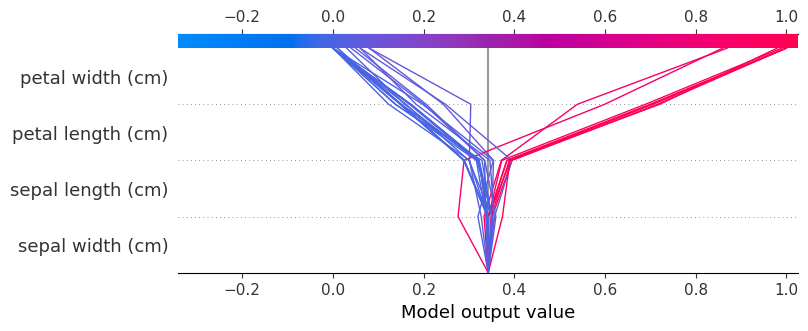

In [28]:
# Plotting a SHAP decision plot (class 1 = versicolor)
shap.decision_plot(explainer.expected_value[1], shap_values[:, :, 1], X_test)

## How to interpret it:

- This decision plot shows how each feature contributes to shifting the model's output from the base value (the model's average prediction over the dataset) to the final prediction for specific instances.
- The x-axis denotes the model output value, which can be interpreted as the probability of a particular class in a classification setting.
- Each line represents an individual prediction's path from the base value to the model output value, with the color indicating the feature's contribution.

## Feature Contributions:

### Petal Width (cm)
- Starts by contributing negatively (moving the prediction to the left) but then shifts to provide positive contributions (moving to the right).

### Petal Length (cm)
- Consistently provides positive contributions (moving the prediction to the right).

### Sepal Length (cm)
- Shows varying impact, with most contributions being positive.

### Sepal Width (cm)
- Generally has a minor negative contribution across different predictions.

## Observations:

- The plot suggests `petal width (cm)` and `petal length (cm)` are the most influential features.
- The separation between lines towards the right side implies that different instances have varied feature impacts leading to different predictions.
- The convergence of lines towards the right side indicates a strong positive contribution from features, especially `petal length (cm)`.